# Automatic Differentiation Using JAX

This notebook introduces **automatic differentiation (AD)**, a third approach to computing derivatives (alongside symbolic and numerical methods). JAX is a powerful library that provides automatic differentiation capabilities for complex functions.

In [32]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import time

## What is Automatic Differentiation?

Automatic differentiation (AD) is a technique to compute exact derivatives of functions expressed as computer programs. It's neither symbolic nor numerical—it's something in between.

### The Three Approaches to Computing Derivatives

| Method | Approach | Accuracy | Speed | Example Library |
|--------|----------|----------|-------|------------------|
| **Symbolic** | Express derivatives as formulas | Exact | Can be slow for complex expressions | SymPy |
| **Numerical** | Approximate using finite differences | Approximate (O(h) to O(h²)) | Fast for arrays, parallel | NumPy |
| **Automatic** | Systematically apply chain rule | Exact (up to floating-point precision) | Very fast, efficient | JAX, PyTorch |

### Why Automatic Differentiation?

**Advantages:**
- **Exact**: Computes derivatives to machine precision (no step size parameter)
- **Efficient**: Can compute gradients of thousands of variables in a single pass
- **Scalable**: Essential for deep learning (computing gradients of neural networks)
- **Flexible**: Works for any Python function, including loops and conditionals
- **No symbolic manipulation needed**: Doesn't require deriving formulas

**Disadvantages:**
- Requires learning a new framework (JAX, PyTorch, TensorFlow)
- Can be overkill for simple functions
- Limited insight into derivative structure (compared to symbolic)

### How Does It Work? The Chain Rule

AD systematically applies the chain rule. For a composite function $y = f(g(x))$:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

AD breaks down complex functions into elementary operations (addition, multiplication, sin, exp, etc.) and applies the chain rule automatically.

### Two Modes of Automatic Differentiation

1. **Forward Mode (Forward-Mode AD)**
   - Computes derivatives propagating from inputs to outputs
   - Efficient for functions with few inputs and many outputs
   - Example: Computing sensitivities to a single input variable

2. **Reverse Mode (Reverse-Mode AD / Backpropagation)**
   - Computes derivatives propagating from outputs back to inputs
   - Efficient for functions with many inputs and few outputs
   - Essential for deep learning (computing gradients of loss functions)
   - Example: Computing gradients of a scalar loss function with respect to thousands of parameters

## JAX Basics: Computing Gradients with jax.grad()

JAX provides `jax.grad()` to compute the gradient of a function.

In [33]:
# Example 1: Simple function f(x) = x^2
def f_quad(x):
    return x**2

# Create the gradient function using jax.grad
grad_f_quad = jax.grad(f_quad)

# Evaluate at different points
x_values = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])

print("="*70)
print("Example 1: f(x) = x^2")
print("Analytical derivative: f'(x) = 2x")
print("="*70)
print()
print("Using JAX:")
for x in x_values:
    grad_value = grad_f_quad(x)
    analytical = 2 * x
    print(f"  f'({x}) = {grad_value:.4f}  (analytical: {analytical:.4f})")

Example 1: f(x) = x^2
Analytical derivative: f'(x) = 2x

Using JAX:
  f'(1.0) = 2.0000  (analytical: 2.0000)
  f'(2.0) = 4.0000  (analytical: 4.0000)
  f'(3.0) = 6.0000  (analytical: 6.0000)
  f'(4.0) = 8.0000  (analytical: 8.0000)
  f'(5.0) = 10.0000  (analytical: 10.0000)


## Example 2: Computing Gradients of Trigonometric Functions

In [34]:
# Example 2: f(x) = sin(x)
def f_sin(x):
    return jnp.sin(x)

grad_f_sin = jax.grad(f_sin)

test = jnp.pi / 4

print()
print("="*70)
print("Example 2: f(x) = sin(x)")
print("Analytical derivative: f'(x) = cos(x)")
print("="*70)
print()
print(f"At x = π/4 ≈ {float(test):.6f}:")
print(f"  JAX gradient:        {float(grad_f_sin(test)):.12f}")
print(f"  Analytical (cos):    {float(jnp.cos(test)):.12f}")
print(f"  Difference:          {abs(float(grad_f_sin(test)) - float(jnp.cos(test))):.2e}")


Example 2: f(x) = sin(x)
Analytical derivative: f'(x) = cos(x)

At x = π/4 ≈ 0.785398:
  JAX gradient:        0.707106769085
  Analytical (cos):    0.707106769085
  Difference:          0.00e+00


## Example 3: Composite Functions and the Chain Rule

In [35]:
# Example 3: Composite function f(x) = sin(x^2)
# Analytical derivative: f'(x) = cos(x^2) * 2x = 2x*cos(x^2)

def f_composite(x):
    return jnp.sin(x**2)

grad_f_composite = jax.grad(f_composite)

# Analytical derivative
def f_composite_analytical(x):
    return 2 * x * jnp.cos(x**2)

print()
print("="*70)
print("Example 3: f(x) = sin(x^2)")
print("Analytical derivative: f'(x) = 2x*cos(x^2)")
print("="*70)

x_test_values = jnp.array([0.5, 1.0, 1.5, 2.0])
print()
print("Comparison:")
for x in x_test_values:
    jax_grad = grad_f_composite(x)
    analytical = f_composite_analytical(x)
    print(f"  x = {x:.1f}: JAX = {jax_grad:10.8f}, Analytical = {analytical:10.8f}, Error = {abs(jax_grad - analytical):.2e}")


Example 3: f(x) = sin(x^2)
Analytical derivative: f'(x) = 2x*cos(x^2)

Comparison:
  x = 0.5: JAX = 0.96891242, Analytical = 0.96891242, Error = 0.00e+00
  x = 1.0: JAX = 1.08060455, Analytical = 1.08060455, Error = 0.00e+00
  x = 1.5: JAX = -1.88452101, Analytical = -1.88452101, Error = 0.00e+00
  x = 2.0: JAX = -2.61457443, Analytical = -2.61457443, Error = 0.00e+00


## Computing Gradients of Vector Functions

JAX can compute gradients with respect to vectors and matrices, which is essential for machine learning.

In [36]:
# Example 4: Function with vector input
# f(x) = ||x||^2 = x1^2 + x2^2 + x3^2 (sum of squares)
# Gradient: ∇f(x) = [2*x1, 2*x2, 2*x3]

def f_sum_of_squares(x):
    """Compute sum of squares: ||x||^2"""
    return jnp.sum(x**2)

grad_f_sum_of_squares = jax.grad(f_sum_of_squares)

print()
print("="*70)
print("Example 4: f(x) = ||x||^2 = x1^2 + x2^2 + x3^2")
print("Gradient: ∇f(x) = [2*x1, 2*x2, 2*x3]")
print("="*70)

x = jnp.array([1.0, 2.0, 3.0])
jax_gradient = grad_f_sum_of_squares(x)
analytical_gradient = 2 * x

print()
print(f"At x = {x}:")
print(f"  JAX gradient:        {jax_gradient}")
print(f"  Analytical gradient: {analytical_gradient}")
print(f"  Difference:          {jnp.max(jnp.abs(jax_gradient - analytical_gradient)):.2e}")


Example 4: f(x) = ||x||^2 = x1^2 + x2^2 + x3^2
Gradient: ∇f(x) = [2*x1, 2*x2, 2*x3]

At x = [1. 2. 3.]:
  JAX gradient:        [2. 4. 6.]
  Analytical gradient: [2. 4. 6.]
  Difference:          0.00e+00


## Higher-Order Derivatives

JAX can compute second derivatives, third derivatives, etc., by composing `grad()` calls.

In [37]:
# Example 5: Higher-order derivatives
# f(x) = x^3
# f'(x) = 3x^2
# f''(x) = 6x
# f'''(x) = 6

def f_cubic(x):
    return x**3

# First derivative
grad_1 = jax.grad(f_cubic)
# Second derivative (gradient of the first derivative)
grad_2 = jax.grad(grad_1)
# Third derivative
grad_3 = jax.grad(grad_2)

print()
print("="*70)
print("Example 5: f(x) = x^3")
print("="*70)
print("  f(x) = x^3")
print("  f'(x) = 3x^2")
print("  f''(x) = 6x")
print("  f'''(x) = 6")
print("="*70)

test = 2.0
print()
print(f"At x = {test}:")
print(f"  f'({test}) = {float(grad_1(jnp.array(test))):.4f}  (analytical: {3*test**2:.4f})")
print(f"  f''({test}) = {float(grad_2(jnp.array(test))):.4f}  (analytical: {6*test:.4f})")
print(f"  f'''({test}) = {float(grad_3(jnp.array(test))):.4f}  (analytical: 6.0000)")


Example 5: f(x) = x^3
  f(x) = x^3
  f'(x) = 3x^2
  f''(x) = 6x
  f'''(x) = 6

At x = 2.0:
  f'(2.0) = 12.0000  (analytical: 12.0000)
  f''(2.0) = 12.0000  (analytical: 12.0000)
  f'''(2.0) = 6.0000  (analytical: 6.0000)


## Vectorized Automatic Differentiation

JAX allows computing gradients at multiple points efficiently using `jax.vmap()`.

/tmp/ipykernel_54046/3902502636.py:52: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


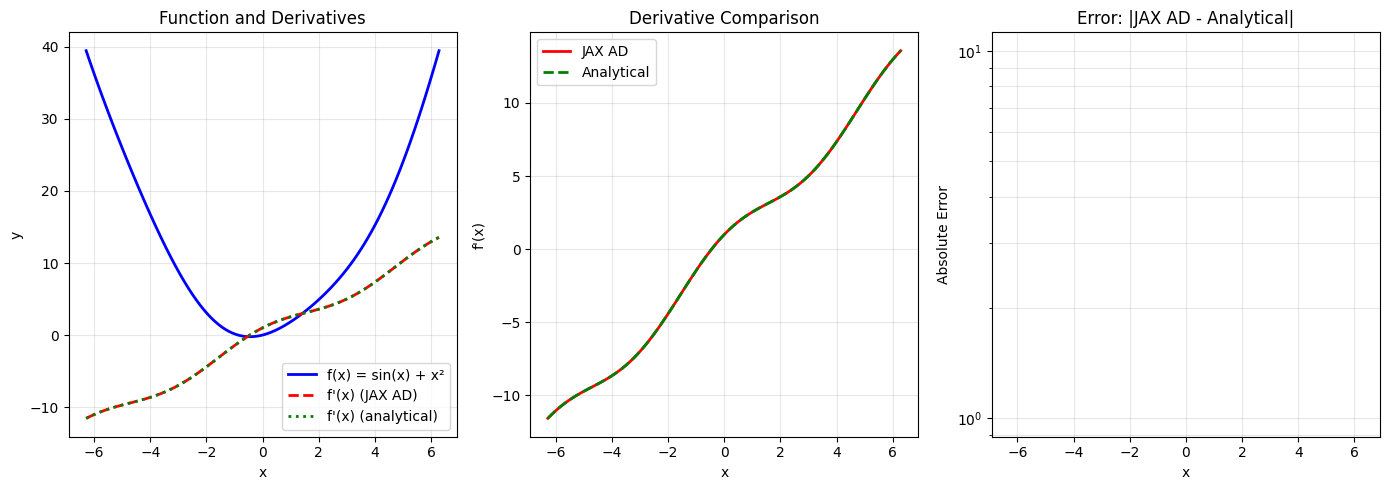


Max error: 0.00e+00
Mean error: 0.00e+00


In [38]:
# Compute gradients at multiple points using vmap
def f_test(x):
    return jnp.sin(x) + x**2

grad_f_test = jax.grad(f_test)

# Vectorize the gradient function to work on arrays
grad_f_vectorized = jax.vmap(grad_f_test)

# Generate x values
x = jnp.linspace(-2*jnp.pi, 2*jnp.pi, 100)

# Compute gradients at all points at once
jax_gradients = grad_f_vectorized(x)

# Analytical gradient: f'(x) = cos(x) + 2x
analytical_gradients = jnp.cos(x) + 2*x

# Plotting
plt.figure(figsize=(14, 5))

# Plot 1: Function and derivatives
plt.subplot(1, 3, 1)
plt.plot(x, f_test(x), 'b-', linewidth=2, label='f(x) = sin(x) + x²')
plt.plot(x, jax_gradients, 'r--', linewidth=2, label="f'(x) (JAX AD)")
plt.plot(x, analytical_gradients, 'g:', linewidth=2, label="f'(x) (analytical)")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function and Derivatives')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: JAX vs Analytical
plt.subplot(1, 3, 2)
plt.plot(x, jax_gradients, 'r-', linewidth=2, label='JAX AD')
plt.plot(x, analytical_gradients, 'g--', linewidth=2, label='Analytical')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Derivative Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Error
plt.subplot(1, 3, 3)
error = jnp.abs(jax_gradients - analytical_gradients)
plt.semilogy(x, error, 'purple', linewidth=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Error: |JAX AD - Analytical|')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print()
print(f"Max error: {jnp.max(error):.2e}")
print(f"Mean error: {jnp.mean(error):.2e}")

## Machine Learning Example: Computing Model Gradients

An important use case of automatic differentiation is computing gradients of loss functions in machine learning.

In [39]:
# Simple linear regression example
# Model: y_pred = a*x + b
# Loss: MSE = (1/n) * sum((y_true - y_pred)^2)

def linear_model(params, x):
    """Linear model: y = a*x + b"""
    a, b = params
    return a * x + b

def mse_loss(params, x, y_true):
    """Mean squared error loss"""
    y_pred = linear_model(params, x)
    return jnp.mean((y_true - y_pred)**2)

# Generate synthetic data
np.random.seed(42)
x_data = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_true = 2.5 * x_data + 1.0 + np.array([0.1, -0.2, 0.15, -0.1, 0.05])  # y = 2.5x + 1 + noise

# Initial parameters
params = jnp.array([1.0, 0.0])  # a=1, b=0

# Compute gradients with respect to parameters
grad_loss = jax.grad(mse_loss)
gradients = grad_loss(params, x_data, y_true)

print()
print("="*70)
print("Machine Learning Example: Computing Model Gradients")
print("="*70)
print()
print(f"Initial parameters: a = {params[0]:.4f}, b = {params[1]:.4f}")
print(f"Initial loss: {float(mse_loss(params, x_data, y_true)):.6f}")
print()
print(f"Gradients (with respect to loss):")
print(f"  ∂L/∂a = {gradients[0]:.6f}")
print(f"  ∂L/∂b = {gradients[1]:.6f}")

# Perform one gradient descent step
learning_rate = 0.01
params_updated = params - learning_rate * gradients

print()
print(f"After one gradient descent step (lr=0.01):")
print(f"  Updated parameters: a = {params_updated[0]:.4f}, b = {params_updated[1]:.4f}")
print(f"  Updated loss: {float(mse_loss(params_updated, x_data, y_true)):.6f}")
print(f"  Loss reduction: {float(mse_loss(params, x_data, y_true)) - float(mse_loss(params_updated, x_data, y_true)):.6f}")


Machine Learning Example: Computing Model Gradients

Initial parameters: a = 1.0000, b = 0.0000
Initial loss: 34.766998

Gradients (with respect to loss):
  ∂L/∂a = -39.000000
  ∂L/∂b = -11.000000

After one gradient descent step (lr=0.01):
  Updated parameters: a = 1.3900, b = 0.1100
  Updated loss: 20.289600
  Loss reduction: 14.477398


## Comparison: Symbolic vs Numerical vs Automatic Differentiation

Let's compare all three approaches on the same function.

In [40]:
# Test function: f(x) = e^x * sin(x)
def f_test_func(x):
    return jnp.exp(x) * jnp.sin(x)

x_val = 1.0

print()
print("="*70)
print("Comparison: Symbolic vs Numerical vs Automatic Differentiation")
print("Function: f(x) = e^x * sin(x)")
print(f"Evaluate at x = {x_val}")
print("="*70)

# 1. Symbolic (using SymPy)
x_sym = sp.Symbol('x')
f_sym = sp.exp(x_sym) * sp.sin(x_sym)
f_prime_sym = sp.diff(f_sym, x_sym)
symbolic_deriv = float(f_prime_sym.subs(x_sym, x_val))

# 2. Numerical (using finite differences)
h = 1e-5
numerical_deriv = (f_test_func(x_val + h) - f_test_func(x_val)) / h

# 3. Automatic (using JAX)
jax_grad_func = jax.grad(f_test_func)
automatic_deriv = jax_grad_func(jnp.array(x_val))

print()
print(f"1. Symbolic (SymPy):        {symbolic_deriv:.12f}")
print(f"2. Numerical (h=1e-5):      {float(numerical_deriv):.12f}")
print(f"3. Automatic (JAX):         {float(automatic_deriv):.12f}")

print()
print(f"Error Analysis (compared to symbolic):")
print(f"  Numerical error:        {abs(float(numerical_deriv) - symbolic_deriv):.2e}")
print(f"  Automatic error:        {abs(float(automatic_deriv) - symbolic_deriv):.2e}")

print()
print(f"Key Observations:")
print(f"  - Symbolic: Exact (no numerical errors)")
print(f"  - Numerical: Approximation error depends on step size h")
print(f"  - Automatic: Exact to machine precision (only floating-point rounding errors)")


Comparison: Symbolic vs Numerical vs Automatic Differentiation
Function: f(x) = e^x * sin(x)
Evaluate at x = 1.0

1. Symbolic (SymPy):        3.756049227095
2. Numerical (h=1e-5):      3.767013549805
3. Automatic (JAX):         3.756049156189

Error Analysis (compared to symbolic):
  Numerical error:        1.10e-02
  Automatic error:        7.09e-08

Key Observations:
  - Symbolic: Exact (no numerical errors)
  - Numerical: Approximation error depends on step size h
  - Automatic: Exact to machine precision (only floating-point rounding errors)


In [41]:
# Timing comparison
# Complex function for performance testing
def complex_func(x):
    """A more complex function"""
    return jnp.sum(jnp.sin(x) * jnp.exp(-x**2) + jnp.cos(x**2))

# Generate test data
x_large = jnp.linspace(-5, 5, 1000)

# Time JAX automatic differentiation
jax_grad_func = jax.vmap(jax.grad(complex_func))

start = time.time()
jax_result = jax_grad_func(x_large)
jax_time = time.time() - start

# Time numerical differentiation
h = 1e-5
start = time.time()
numerical_result = (complex_func(x_large + h) - complex_func(x_large)) / h
numerical_time = time.time() - start

print()
print("="*70)
print("Performance Comparison (1000 points)")
print("="*70)
print()
print(f"JAX Automatic Differentiation: {jax_time*1000:.3f} ms")
print(f"Numerical Differentiation:     {numerical_time*1000:.3f} ms")
print()
print(f"Speedup: {numerical_time/jax_time:.1f}x")
print()
print("Note: JAX with JIT compilation can be even faster!")


Performance Comparison (1000 points)

JAX Automatic Differentiation: 7.973 ms
Numerical Differentiation:     1.510 ms

Speedup: 0.2x

Note: JAX with JIT compilation can be even faster!


## Summary: When to Use Each Approach

| Aspect | Symbolic (SymPy) | Numerical (NumPy) | Automatic (JAX) |
|--------|------------------|-------------------|----------|
| **Accuracy** | Exact | Approximate (O(h) to O(h²)) | Exact (floating-point) |
| **Speed** | Can be slow for complex expressions | Fast for arrays | Very fast, efficient |
| **Ease of use** | Medium (requires formula derivation) | Easy | Easy (just write Python) |
| **Insight** | High (you get the formula for f'(x)) | Low | Medium |
| **Scalability** | Limited (complex expressions blow up) | Good for arrays | Excellent (millions of variables) |
| **Use case** | Mathematical analysis, understanding | Empirical data, quick checks | Machine learning, optimization |
| **Step size tuning** | N/A | Yes, crucial | No |

### Recommended Usage:

**Use Symbolic:**
- Teaching and learning calculus
- Mathematical proofs and derivations
- When you need the exact formula for f'(x)
- Simple to moderately complex functions

**Use Numerical:**
- Quick sanity checks on derivatives
- Verifying other methods
- When working with empirical data
- Limited computational budgets

**Use Automatic (JAX):**
- Deep learning and neural networks
- Optimization problems with many variables
- Scientific computing and simulations
- Production systems needing efficiency
- When you need fast, accurate gradients of arbitrary functions